In [1]:
import os
from pathlib import Path
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp
from pydmd import DMD
from rich.console import Console
from rich.table import Table

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "tdmd").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use("ggplot")


In [2]:
nx = 64
ny = 64
nt = 128
train_steps = 96

x = jnp.linspace(-1.0, 1.0, nx)
y = jnp.linspace(-1.0, 1.0, ny)
t = jnp.linspace(0.0, 2.0 * jnp.pi, nt)
X, Y, T = jnp.meshgrid(x, y, t, indexing="ij")

Xf = 5.0 * X - 5.0
Yf = 5.0 * Y - 5.0
R = jnp.sqrt(Xf**2 + Yf**2)
Theta = jnp.arctan2(Yf, Xf + 1.0e-6)

Z = (
    7.0 * jnp.sin(1.7 * Xf + 0.9 * T)
    + 6.0 * jnp.cos(1.3 * Yf - 1.2 * T)
    + 5.0 * jnp.sin(0.9 * (Xf + Yf) + 0.7 * T)
    + 4.0 * jnp.cos(2.2 * R - 1.8 * T)
    + 3.0 * jnp.sin(3.0 * Theta + 0.6 * R - 1.1 * T)
    + 2.5 * jnp.cos(1.8 * (Xf - Yf) + 0.3 * R + 0.8 * T)
)


In [3]:
train_sequence = np.asarray(Z[:, :, :train_steps], dtype=np.float32)
pred_idx = train_sequence.shape[2]
snapshots = train_sequence.reshape(train_sequence.shape[0] * train_sequence.shape[1], -1)
pred_steps = np.arange(pred_idx + 1)


In [4]:
rank = 30
model = DMD(svd_rank=rank, exact=False)
model.fit(snapshots)

modes = np.asarray(model.modes)
eigenvalues = np.asarray(model.eigs)
amplitudes = np.asarray(model.amplitudes)

pred_sequence = []
state_errors = []
for step in pred_steps:
    snapshot_pred = modes @ ((eigenvalues**step) * amplitudes)
    snapshot_pred = np.asarray(snapshot_pred.reshape(Z.shape[0], Z.shape[1])).real
    pred_sequence.append(snapshot_pred)
    state_errors.append(
        np.linalg.norm(np.asarray(Z[:, :, step]) - snapshot_pred) / np.linalg.norm(np.asarray(Z[:, :, step]))
    )

pred_sequence = np.asarray(pred_sequence)
state_errors = np.asarray(state_errors)
snapshot_true = np.asarray(Z[:, :, pred_idx])
snapshot_pred = pred_sequence[pred_idx]
snapshot_re = float(state_errors[pred_idx])

table = Table(title="Plasma DMD")
table.add_column("Name", no_wrap=True)
table.add_column("Value")
table.add_row("sequence shape", f"{tuple(Z.shape)}")
table.add_row("rank", f"{rank}")
table.add_row("mean state-wise RE", f"{state_errors.mean():.4e}")
table.add_row("max state-wise RE", f"{state_errors.max():.4e}")
table.add_row("snapshot RE", f"{snapshot_re:.4e}")
Console().print(table)


/usr/local/lib/python3.12/dist-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 123409952.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


              Plasma DMD              
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Name               ┃ Value         ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequence shape     │ (64, 64, 128) │
│ rank               │ 30            │
│ mean state-wise RE │ 1.6249e-06    │
│ max state-wise RE  │ 2.9746e-06    │
│ snapshot RE        │ 2.9746e-06    │
└────────────────────┴───────────────┘

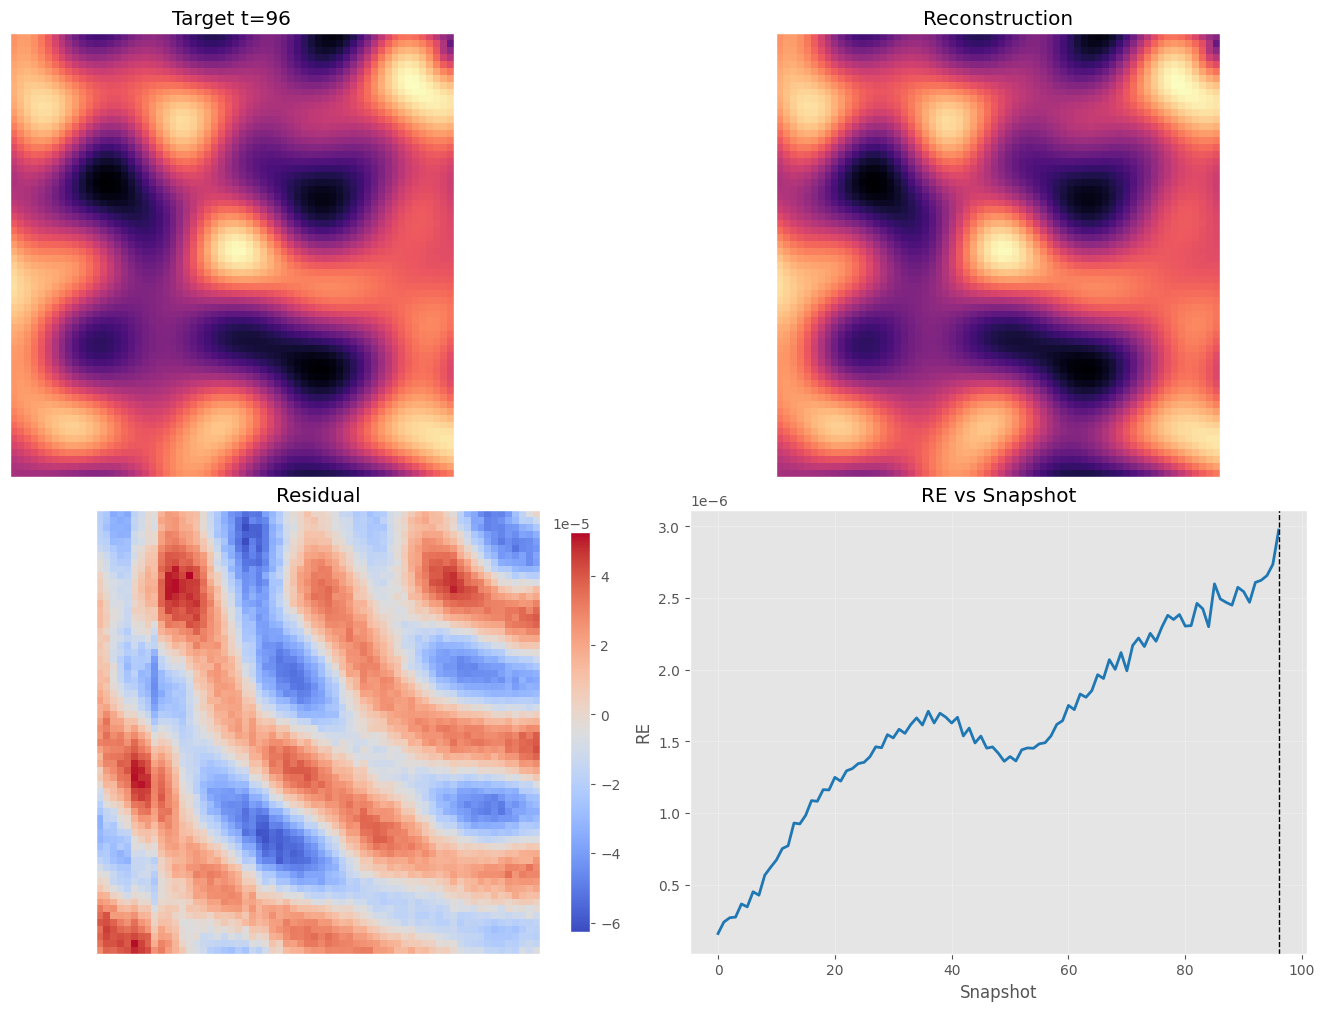

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

axes[0, 0].imshow(snapshot_true, origin="lower", cmap="magma")
axes[0, 0].set_title(f"Target t={pred_idx}")
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks([])

axes[0, 1].imshow(snapshot_pred, origin="lower", cmap="magma")
axes[0, 1].set_title("Reconstruction")
axes[0, 1].set_xticks([])
axes[0, 1].set_yticks([])

residual_img = axes[1, 0].imshow(snapshot_true - snapshot_pred, origin="lower", cmap="coolwarm")
axes[1, 0].set_title("Residual")
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])
fig.colorbar(residual_img, ax=axes[1, 0], shrink=0.9, pad=0.02)

axes[1, 1].plot(pred_steps, state_errors, linewidth=2, color="tab:blue")
axes[1, 1].axvline(pred_idx, color="black", linestyle="--", linewidth=1)
axes[1, 1].set_title("RE vs Snapshot")
axes[1, 1].set_xlabel("Snapshot")
axes[1, 1].set_ylabel("RE")
axes[1, 1].grid(True, alpha=0.3)

plt.show()
